# 📱 Smartphone Usage & Behavioral Addiction Prediction

## Machine Learning Project

### Objectives
- Perform Exploratory Data Analysis (EDA)
- Understand smartphone usage patterns
- Build a Machine Learning model
- Predict whether a user is addicted or not addicted

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Step 1: Load the Dataset

In this step, we load the smartphone addiction dataset into a pandas DataFrame.

In [2]:
df = pd.read_csv("mobile_addiction.csv")

df.head()

,Unnamed: 0,daily_screen_time,app_sessions,social_media_usage,gaming_time,notifications,night_usage,age,work_study_hours,stress_level,apps_installed,addicted
0,0,2,29,0,0,49,0,44,5,3,35,not addicted
1,1,6,29,1,2,65,1,29,5,9,21,addicted
2,2,9,28,2,0,57,3,28,7,5,39,addicted
3,3,6,39,2,0,69,1,28,6,8,24,addicted
4,4,5,37,3,1,64,2,27,4,5,26,addicted


# Step 2: Explore the Dataset

Let's inspect the dataset structure including:
- Number of rows and columns
- Data types
- Column names

In [3]:
print(df.info())

print("\nShape:", df.shape)

print("\nColumns")

print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13589 entries, 0 to 13588
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          13589 non-null  int64 
 1   daily_screen_time   13589 non-null  int64 
 2   app_sessions        13589 non-null  int64 
 3   social_media_usage  13589 non-null  int64 
 4   gaming_time         13589 non-null  int64 
 5   notifications       13589 non-null  int64 
 6   night_usage         13589 non-null  int64 
 7   age                 13589 non-null  int64 
 8   work_study_hours    13589 non-null  int64 
 9   stress_level        13589 non-null  int64 
 10  apps_installed      13589 non-null  int64 
 11  addicted            13589 non-null  object
dtypes: int64(11), object(1)
memory usage: 1.2+ MB
None

Shape: (13589, 12)

Columns
Index(['Unnamed: 0', 'daily_screen_time', 'app_sessions', 'social_media_usage',
       'gaming_time', 'notifications', 'night_usage', 

# Step 3: Statistical Summary

Generate descriptive statistics for all numerical features.

In [4]:
df.describe()

,Unnamed: 0,daily_screen_time,app_sessions,social_media_usage,gaming_time,notifications,night_usage,age,work_study_hours,stress_level,apps_installed
count,13589.000000,13589.000000,13589.000000,13589.000000,13589.000000,13589.000000,13589.000000,13589.000000,13589.00000,13589.000000,13589.000000
mean,6794.000000,3.768121,30.037604,1.545956,1.034219,60.015306,0.990213,33.055707,5.97807,4.265288,27.532048
std,3922.950739,1.897280,7.406585,1.204830,0.993172,12.732064,0.946606,10.118145,2.07139,2.288454,5.894790
min,0.000000,0.000000,8.000000,0.000000,0.000000,25.000000,0.000000,15.000000,0.00000,0.000000,10.000000
25%,3397.000000,2.000000,25.000000,1.000000,0.000000,50.000000,0.000000,25.000000,5.00000,3.000000,23.000000
50%,6794.000000,4.000000,30.000000,1.000000,1.000000,59.000000,1.000000,33.000000,6.00000,4.000000,27.000000
75%,10191.000000,5.000000,35.000000,2.000000,2.000000,70.000000,2.000000,41.000000,7.00000,6.000000,31.000000
max,13588.000000,12.000000,60.000000,7.000000,6.000000,103.000000,6.000000,55.000000,14.00000,10.000000,55.000000


# Step 4: Data Cleaning

Remove unnecessary columns such as index columns if present.

In [5]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,daily_screen_time,app_sessions,social_media_usage,gaming_time,notifications,night_usage,age,work_study_hours,stress_level,apps_installed,addicted
0,2,29,0,0,49,0,44,5,3,35,not addicted
1,6,29,1,2,65,1,29,5,9,21,addicted
2,9,28,2,0,57,3,28,7,5,39,addicted
3,6,39,2,0,69,1,28,6,8,24,addicted
4,5,37,3,1,64,2,27,4,5,26,addicted


# Step 5: Missing Value Analysis

Check whether the dataset contains missing values.

In [6]:
df.isnull().sum()

daily_screen_time     0
app_sessions          0
social_media_usage    0
gaming_time           0
notifications         0
night_usage           0
age                   0
work_study_hours      0
stress_level          0
apps_installed        0
addicted              0
dtype: int64

# Step 6: Duplicate Records

Identify duplicate rows in the dataset.

In [7]:
print(df.duplicated().sum())

0


# Step 7: Target Variable Distribution

Visualize the number of addicted and not addicted users.

In [8]:
df["addicted"].value_counts()

addicted
addicted        6846
not addicted    6743
Name: count, dtype: int64

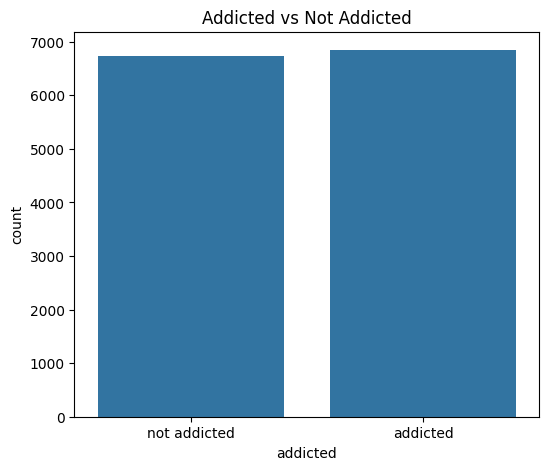

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(x="addicted", data=df)

plt.title("Addicted vs Not Addicted")

plt.show()

# Step 8: Feature Distribution

Plot histograms to understand the distribution of each feature.

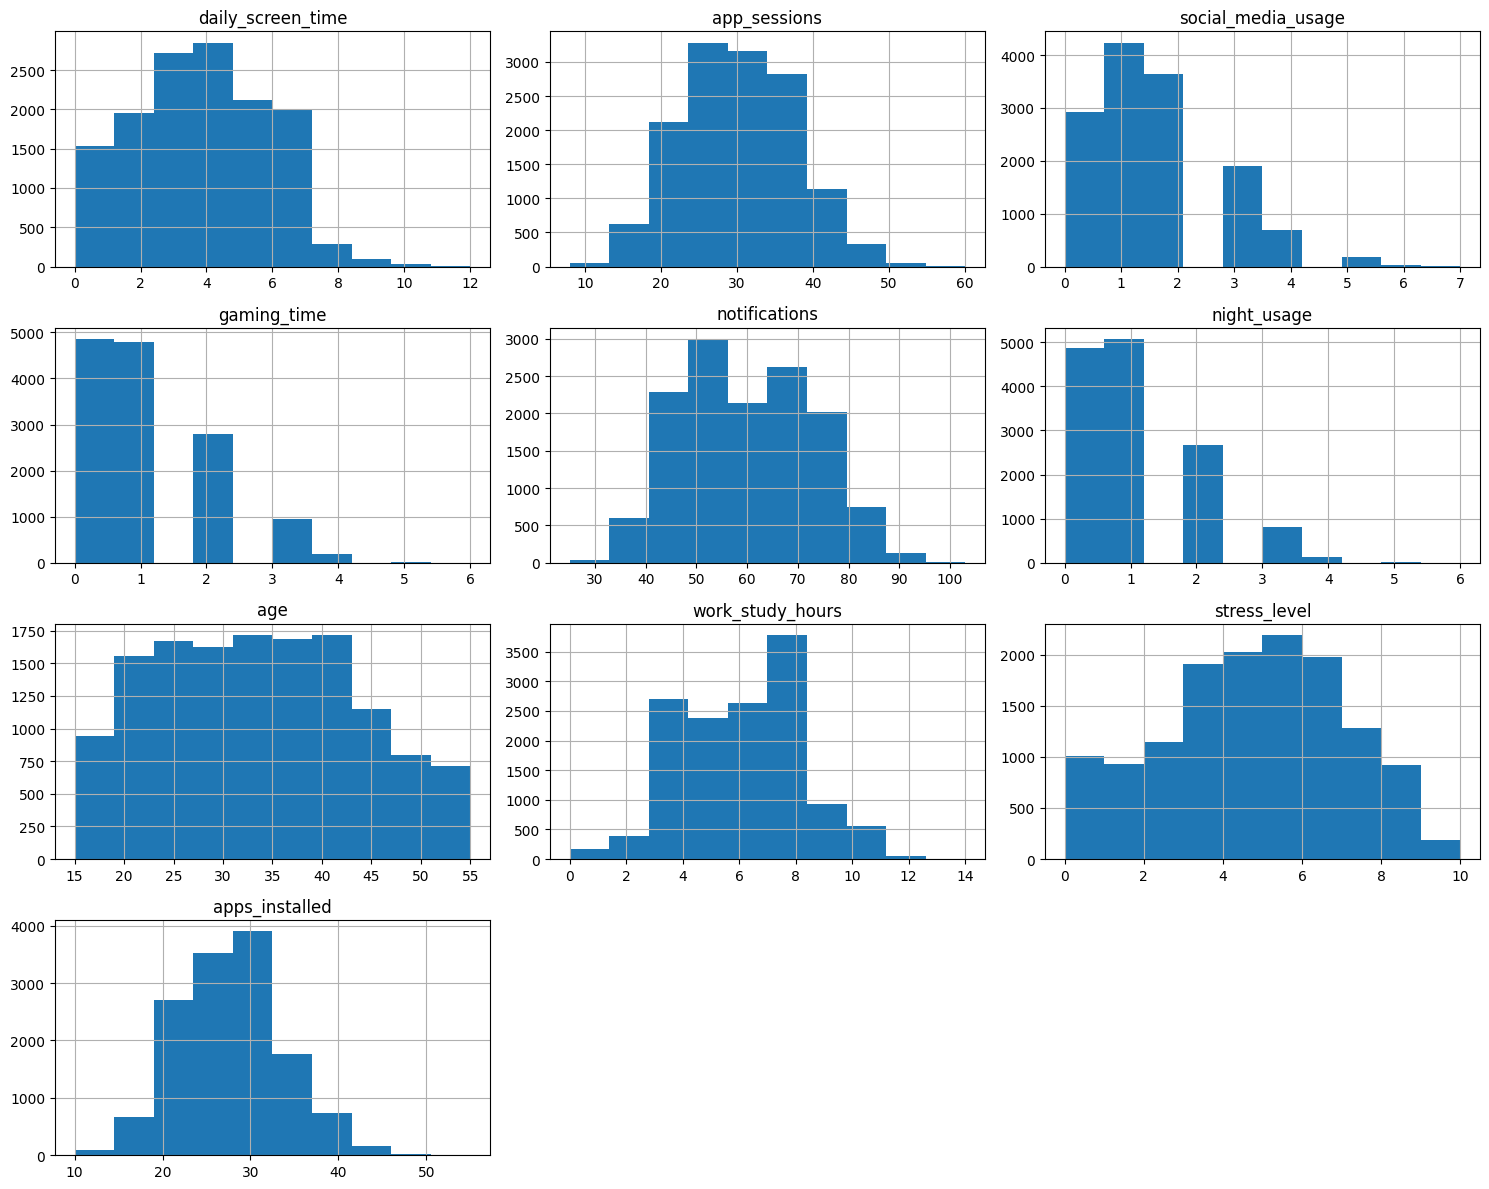

In [10]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

# Step 9: Correlation Heatmap

Analyze relationships among numerical variables.

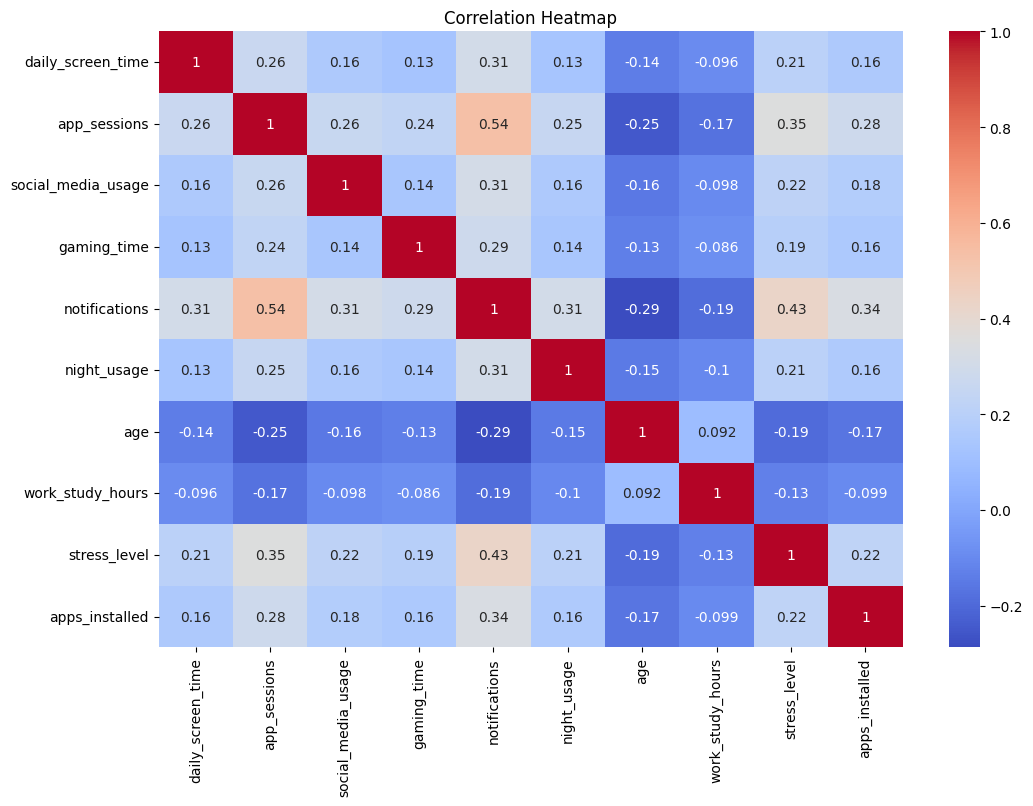

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("addicted", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Step 10: Boxplots

Detect outliers in numerical features.

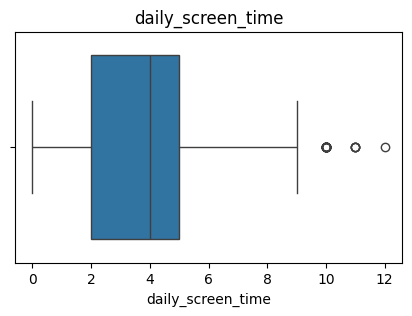

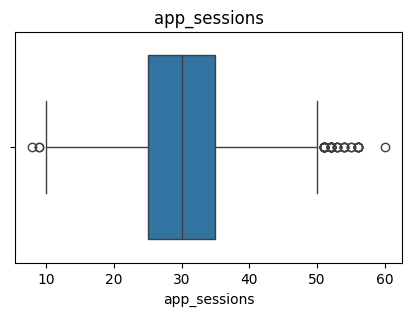

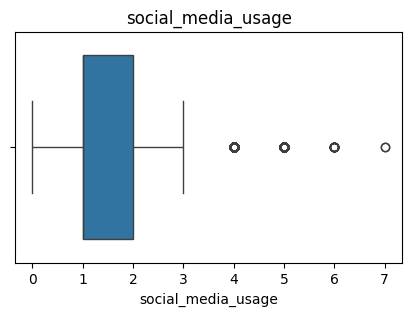

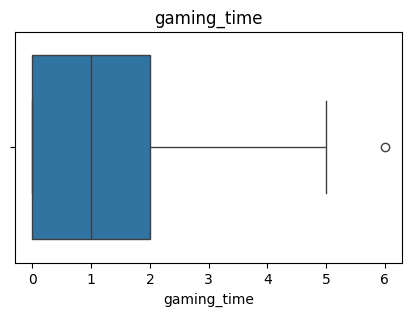

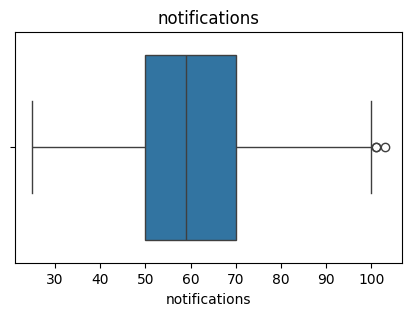

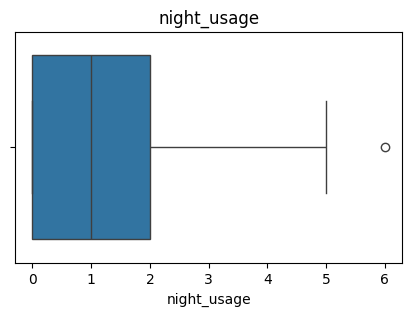

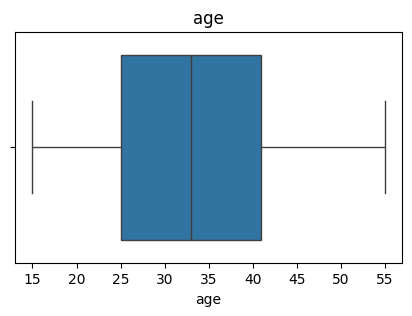

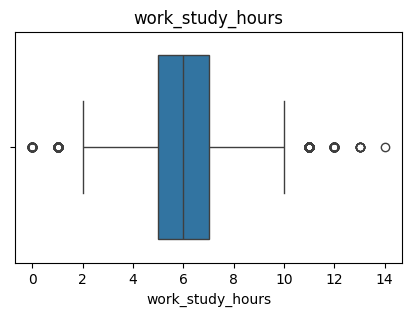

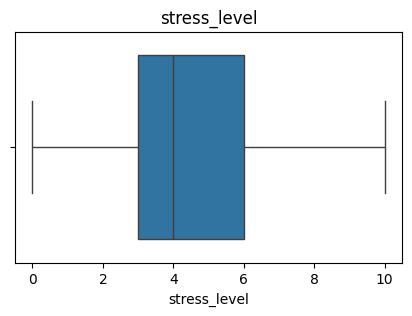

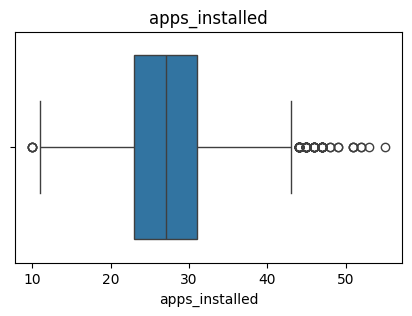

In [12]:
for col in df.columns[:-1]:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

# Step 11: Prepare Features and Target Variable

Separate independent variables (X) and target variable (y).

In [13]:
X = df.drop("addicted", axis=1)

y = df["addicted"]

# Step 12: Encode the Target Variable

Convert text labels into numerical values.

In [14]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(encoder.classes_)

['addicted' 'not addicted']


# Step 13: Split the Dataset

Divide the dataset into training and testing sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 14: Train the Random Forest Model

Train the classifier using the training dataset.

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Step 15: Make Predictions

Predict addiction status for the test dataset.

In [17]:
y_pred = model.predict(X_test)

# Step 16: Evaluate Model Accuracy

Calculate prediction accuracy.

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 97.79 %


# Step 17: Classification Report

Display Precision, Recall and F1-score.

In [19]:
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

    addicted       0.98      0.98      0.98      1369
not addicted       0.98      0.98      0.98      1349

    accuracy                           0.98      2718
   macro avg       0.98      0.98      0.98      2718
weighted avg       0.98      0.98      0.98      2718



# Step 18: Confusion Matrix

Visualize model performance using a confusion matrix.

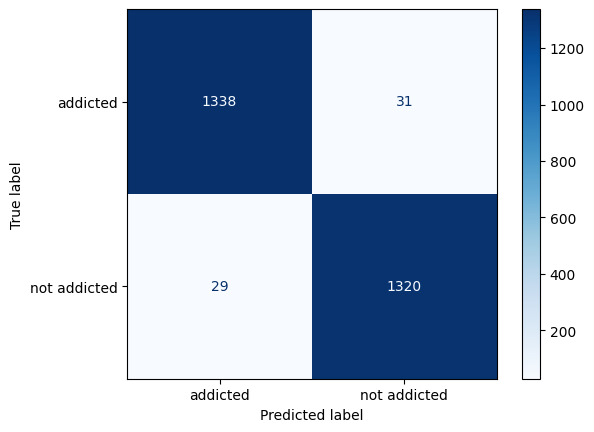

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

# Step 19: ROC Curve

Evaluate classification performance using the ROC Curve.

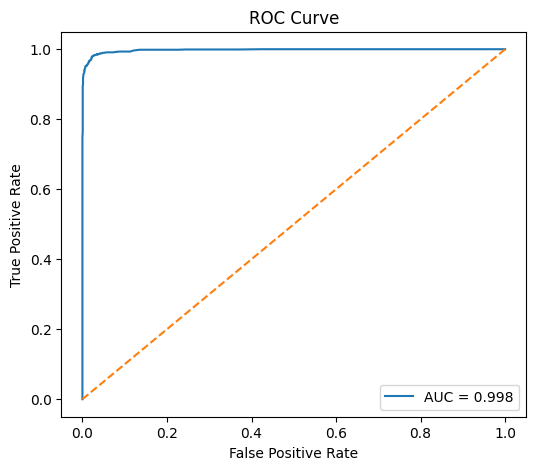

In [21]:
prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="AUC = %.3f"%roc_auc)

plt.plot([0,1],[0,1],'--')

plt.legend()

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

# Step 20: Feature Importance

Identify the most influential features used by the model.

In [22]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,notifications,0.471704
1,app_sessions,0.196656
8,stress_level,0.118228
6,age,0.076409
9,apps_installed,0.046730
0,daily_screen_time,0.023582
2,social_media_usage,0.021322
5,night_usage,0.018291
3,gaming_time,0.015645
7,work_study_hours,0.011434


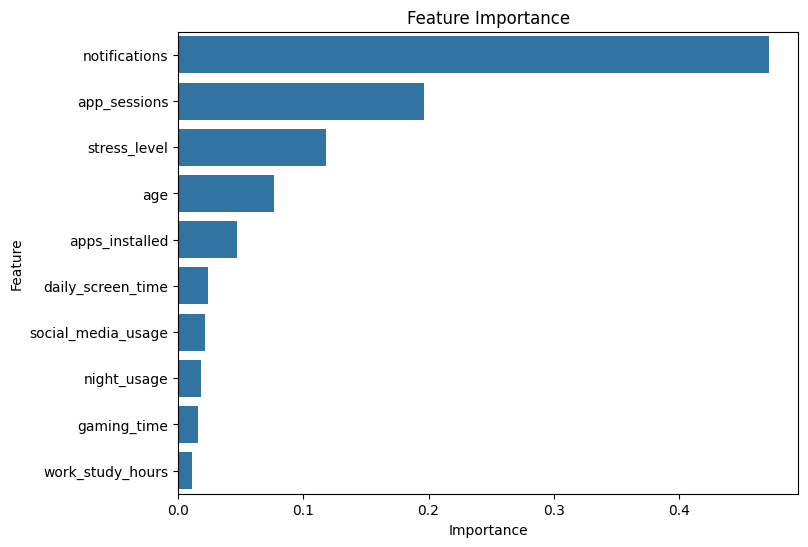

In [23]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# Step 21: Predict Addiction for a New User

Provide user information and predict whether the user is addicted or not.

In [24]:
new_user = pd.DataFrame({
    "daily_screen_time":[8],
    "app_sessions":[85],
    "social_media_usage":[5],
    "gaming_time":[3],
    "notifications":[120],
    "night_usage":[4],
    "age":[22],
    "work_study_hours":[5],
    "stress_level":[8],
    "apps_installed":[60]
})

prediction = model.predict(new_user)

print("Prediction:", encoder.inverse_transform(prediction)[0])

Prediction: addicted


# Step 22: Prediction Probability

Display the probability of each class.

In [25]:
probability = model.predict_proba(new_user)

for label, p in zip(encoder.classes_, probability[0]):
    print(label, ":", round(p*100,2), "%")

addicted : 100.0 %
not addicted : 0.0 %


# 🎉 Conclusion

This notebook successfully:

- Loaded and explored the dataset
- Performed data cleaning
- Conducted Exploratory Data Analysis (EDA)
- Visualized important patterns
- Trained a Random Forest classifier
- Evaluated model performance
- Identified important features
- Predicted smartphone addiction status for new users

The trained model can be further improved by comparing multiple machine learning algorithms such as Logistic Regression, Decision Tree, SVM, KNN, XGBoost, and LightGBM.